In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('SBAcase.11.13.17.csv')
df.head(10)

,Selected,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,...,ChgOffPrinGr,GrAppv,SBA_Appv,New,RealEstate,Portion,Recession,daysterm,xx,Default
0,0,1004285007,SIMPLEX OFFICE SOLUTIONS,ANAHEIM,CA,92801,CALIFORNIA BANK & TRUST,CA,532420,15074,...,0,30000,15000,0,0,0.50,0,1080,16175.0,0
1,1,1004535010,DREAM HOME REALTY,TORRANCE,CA,90505,CALIFORNIA BANK & TRUST,CA,531210,15130,...,0,30000,15000,0,0,0.50,1,1680,17658.0,0
2,0,1005005006,"Winset, Inc. dba Bankers Hill",SAN DIEGO,CA,92103,CALIFORNIA BANK & TRUST,CA,531210,15188,...,0,30000,15000,0,0,0.50,0,1080,16298.0,0
3,1,1005535001,Shiva Management,SAN DIEGO,CA,92108,CALIFORNIA BANK & TRUST,CA,531312,15719,...,0,50000,25000,0,0,0.50,0,1080,16816.0,0
4,1,1005996006,"GOLD CROWN HOME LOANS, INC",LOS ANGELES,CA,91345,SBA - EDF ENFORCEMENT ACTION,CO,531390,16840,...,0,343000,343000,0,1,1.00,0,7200,24103.0,0
5,1,1006295003,Ronald Lee Roberts,SACRAMENTO,CA,95831,CALIFORNIA BANK & TRUST,CA,531210,15813,...,0,50000,25000,0,0,0.50,0,2520,18345.0,0
6,0,1015066002,SUPERIOR BROKERS REALTY,HUNTINGTON PARK,CA,90255,U.S. BANK NATIONAL ASSOCIATION,OH,531210,16841,...,247074,297500,223125,0,1,0.75,0,8070,24930.0,1
7,0,1015266003,LIBERTY REALTY CO,LONG BEACH,CA,90808,JPMORGAN CHASE BANK NATL ASSOC,NV,531210,16841,...,0,30000,15000,1,0,0.50,0,2520,19380.0,0
8,0,1018975003,"SOUTHLAND MGT., CO.",SANTA ANA,CA,92704,BANK OF AMERICA NATL ASSOC,NC,531390,16252,...,35333,50000,25000,0,0,0.50,0,660,16943.0,1
9,1,1022515008,"AMR Appraisals, Inc.",SAN RAMON,CA,94583,BANK OF AMERICA NATL ASSOC,NC,531320,16264,...,0,10000,5000,1,0,0.50,0,2520,18834.0,0


### Statistical summary of the data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2102 entries, 0 to 2101
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Selected           2102 non-null   int64  
 1   LoanNr_ChkDgt      2102 non-null   int64  
 2   Name               2102 non-null   object 
 3   City               2102 non-null   object 
 4   State              2102 non-null   object 
 5   Zip                2102 non-null   int64  
 6   Bank               2099 non-null   object 
 7   BankState          2099 non-null   object 
 8   NAICS              2102 non-null   int64  
 9   ApprovalDate       2102 non-null   int64  
 10  ApprovalFY         2102 non-null   int64  
 11  Term               2102 non-null   int64  
 12  NoEmp              2102 non-null   int64  
 13  NewExist           2101 non-null   float64
 14  CreateJob          2102 non-null   int64  
 15  RetainedJob        2102 non-null   int64  
 16  FranchiseCode      2102 

The dataset comprises of 35 columns and 2102 observations.

In [4]:
df.describe(include='object')

,Name,City,State,Bank,BankState,RevLineCr,LowDoc,MIS_Status
count,2102,2102,2102,2099,2099,2100,2099,2102
unique,2005,519,1,154,21,4,5,2
top,BLUE WATER PARTY RENTALS,LOS ANGELES,CA,BANK OF AMERICA NATL ASSOC,CA,Y,N,P I F
freq,3,162,2102,345,985,737,2053,1416


We need to deal with the categorical columns.

In [5]:
df.describe()

,Selected,LoanNr_ChkDgt,Zip,NAICS,ApprovalDate,ApprovalFY,Term,NoEmp,NewExist,CreateJob,...,ChgOffPrinGr,GrAppv,SBA_Appv,New,RealEstate,Portion,Recession,daysterm,xx,Default
count,2102.000000,2.102000e+03,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2101.000000,2102.000000,...,2.102000e+03,2.102000e+03,2.102000e+03,2102.000000,2102.000000,2102.000000,2102.000000,2102.000000,2099.000000,2102.000000
mean,0.500000,4.469172e+09,92698.612274,531630.902950,16179.587060,2004.035680,126.980495,10.150809,1.153736,2.549952,...,2.002908e+04,2.330641e+05,1.891759e+05,0.154139,0.274500,0.671055,0.068506,3809.414843,20076.896141,0.326356
std,0.500119,2.530069e+09,1878.208435,521.836986,1454.931276,4.006321,93.798944,34.402420,0.362099,8.010175,...,7.543229e+04,3.436310e+05,2.989268e+05,0.361168,0.446368,0.186519,0.252673,2813.968318,2854.510377,0.468991
min,0.000000,1.004285e+09,65757.000000,531110.000000,10554.000000,1989.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,4.500000e+03,2.250000e+03,0.000000,0.000000,0.296770,0.000000,0.000000,11524.000000,0.000000
25%,0.000000,2.392978e+09,91402.000000,531210.000000,15695.750000,2003.000000,60.000000,2.000000,1.000000,0.000000,...,0.000000e+00,3.000000e+04,1.500000e+04,0.000000,0.000000,0.500000,0.000000,1800.000000,18316.500000,0.000000
50%,0.500000,3.621730e+09,92559.500000,531312.000000,16556.000000,2005.000000,84.000000,3.000000,1.000000,0.000000,...,0.000000e+00,6.100000e+04,4.168000e+04,0.000000,0.000000,0.500000,0.000000,2520.000000,19270.000000,0.000000
75%,1.000000,6.551607e+09,94127.750000,532230.000000,17149.750000,2007.000000,240.000000,8.000000,1.000000,2.000000,...,1.507350e+04,3.000000e+05,2.397562e+05,0.000000,1.000000,0.850000,0.000000,7200.000000,22335.000000,1.000000
max,1.000000,9.958873e+09,96161.000000,533110.000000,18911.000000,2012.000000,306.000000,650.000000,2.000000,130.000000,...,1.509550e+06,2.350000e+06,2.115000e+06,1.000000,1.000000,1.000000,1.000000,9180.000000,27598.000000,1.000000


### Checking for missing values

In [6]:
df.isnull().sum()

Selected                0
LoanNr_ChkDgt           0
Name                    0
City                    0
State                   0
Zip                     0
Bank                    3
BankState               3
NAICS                   0
ApprovalDate            0
ApprovalFY              0
Term                    0
NoEmp                   0
NewExist                1
CreateJob               0
RetainedJob             0
FranchiseCode           0
UrbanRural              0
RevLineCr               2
LowDoc                  3
ChgOffDate           1405
DisbursementDate        3
DisbursementGross       0
BalanceGross            0
MIS_Status              0
ChgOffPrinGr            0
GrAppv                  0
SBA_Appv                0
New                     0
RealEstate              0
Portion                 0
Recession               0
daysterm                0
xx                      3
Default                 0
dtype: int64

The missing values in some of the columns need to be dealt with.

### Data Preprocessing

#### 1. Dropping non-useful columns

In [7]:
new_df = df.drop(columns = ['ChgOffDate', 'City', 'State', 'Bank', 'BankState'], axis = 1)

In [8]:
new_df.shape

(2102, 30)

The non-useful columns have been dropped succesfully.

#### 2. Dealing with missing values

In [9]:
# Let us check which columns have missing values
new_df.isnull().sum()

Selected             0
LoanNr_ChkDgt        0
Name                 0
Zip                  0
NAICS                0
ApprovalDate         0
ApprovalFY           0
Term                 0
NoEmp                0
NewExist             1
CreateJob            0
RetainedJob          0
FranchiseCode        0
UrbanRural           0
RevLineCr            2
LowDoc               3
DisbursementDate     3
DisbursementGross    0
BalanceGross         0
MIS_Status           0
ChgOffPrinGr         0
GrAppv               0
SBA_Appv             0
New                  0
RealEstate           0
Portion              0
Recession            0
daysterm             0
xx                   3
Default              0
dtype: int64

Columns with missing values ---> **NewExist**, **RevLineCr**, **LowDoc**, **DisbursementDate**, **xx**

In [10]:
# Since the missing values are relatively low, we can go ahead to directly drop the missing values
new_df = new_df.dropna()

9 observations were dropped from the dataset making the total no. of observations to be 2093.

### 3. Dealing with the categorical columns

In [11]:
new_df.describe(include = 'object')

,Name,RevLineCr,LowDoc,MIS_Status
count,2093,2093,2093,2093
unique,1996,4,5,2
top,WEST COAST VIDEO,Y,N,P I F
freq,3,733,2047,1408


In [12]:
new_df['RevLineCr'].value_counts()

RevLineCr
Y    733
0    729
N    578
T     53
Name: count, dtype: int64

In [13]:
new_df['LowDoc'].value_counts()

LowDoc
N    2047
Y      41
S       3
A       1
0       1
Name: count, dtype: int64

In [14]:
new_df['MIS_Status'].value_counts()

MIS_Status
P I F     1408
CHGOFF     685
Name: count, dtype: int64

In [15]:
RevLineCr_mapping = {'Y' : 0, '0' : 1, 'N' : 2, 'T' : 3,}

new_df['RevLineCr'] = df['RevLineCr'].map(RevLineCr_mapping)

In [16]:
lowDoc_mapping = {'N' : 0, 'Y' : 1, 'S' : 2, 'A' : 3, '0' : 4}

new_df['LowDoc'] = new_df['LowDoc'].map(lowDoc_mapping)

In [17]:
mapping = {'P I F': 0, 'CHGOFF' : 1}

new_df['MIS_Status'] = df['MIS_Status'].map(mapping)

In [18]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2093 entries, 0 to 2100
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Selected           2093 non-null   int64  
 1   LoanNr_ChkDgt      2093 non-null   int64  
 2   Name               2093 non-null   object 
 3   Zip                2093 non-null   int64  
 4   NAICS              2093 non-null   int64  
 5   ApprovalDate       2093 non-null   int64  
 6   ApprovalFY         2093 non-null   int64  
 7   Term               2093 non-null   int64  
 8   NoEmp              2093 non-null   int64  
 9   NewExist           2093 non-null   float64
 10  CreateJob          2093 non-null   int64  
 11  RetainedJob        2093 non-null   int64  
 12  FranchiseCode      2093 non-null   int64  
 13  UrbanRural         2093 non-null   int64  
 14  RevLineCr          2093 non-null   float64
 15  LowDoc             2093 non-null   int64  
 16  DisbursementDate   2093 non-n

The 3 categorical columns have been dealt with

### Splitting the data

In [19]:
# Features
X = new_df.drop(columns = ['Name', 'Default'], axis = 1).values

# Target
y = new_df['Default'].values

In [20]:
# Splitting the data using training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size = 0.2, random_state = 365)

In [21]:
print(X.shape, X_train.shape, X_test.shape)

(2093, 28) (1674, 28) (419, 28)


### Standardize the Numerical features

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
# Create the scaler object
scaler = StandardScaler()

In [24]:
# Apply the fit_transform on the training set
X_train_scaled = scaler.fit_transform(X_train)

In [25]:
# Transform the test set
X_test_scaled = scaler.transform(X_test)

In [26]:
X_train_scaled

array([[ 0.98812309, -1.23308853, -1.29078682, ..., -0.26520272,
        -0.45450765, -0.32403493],
       [-1.01201966,  0.8641419 ,  0.1878732 , ..., -0.26520272,
        -0.45450765, -0.17358829],
       [ 0.98812309, -1.17313901, -0.02463511, ..., -0.26520272,
         1.85367625,  0.96198436],
       ...,
       [ 0.98812309, -0.90180405, -0.33502286, ..., -0.26520272,
        -0.45450765, -0.05590872],
       [-1.01201966, -0.91786609,  0.10569634, ..., -0.26520272,
        -0.45450765, -0.1415259 ],
       [-1.01201966, -0.54359569, -0.17380966, ..., -0.26520272,
         1.85367625,  1.20861819]])

In [27]:
X_test_scaled

array([[-1.01201966, -0.80205887, -0.0701726 , ..., -0.26520272,
        -0.56136801, -0.18310131],
       [ 0.98812309, -1.00084142, -0.69199494, ..., -0.26520272,
        -0.45450765, -0.17358829],
       [-1.01201966, -0.85223   ,  1.54038912, ..., -0.26520272,
        -0.68960045, -0.34235631],
       ...,
       [ 0.98812309, -0.0603391 ,  0.06643988, ..., -0.26520272,
        -0.45450765, -2.17872138],
       [-1.01201966,  1.24517046,  1.16405052, ..., -0.26520272,
        -1.11704192, -1.08613349],
       [ 0.98812309,  2.15037821, -0.17328624, ..., -0.26520272,
        -0.71097253, -0.48117592]])

### Building the Logistic Regression Model

In [28]:
from sklearn.linear_model import LogisticRegression

In [29]:
# Create and instance of the model
l_model = LogisticRegression()

In [30]:
# Fit the model
l_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [31]:
# Make predictions on the training set
training_pred = l_model.predict(X_train_scaled)

In [32]:
# Evaluate the model performance on the training set
from sklearn.metrics import accuracy_score, confusion_matrix
print('Training Accuracy: ', accuracy_score(y_train, training_pred))

Training Accuracy:  1.0


The training accuracy of the Logistic Regression Model is exactly 100% (We might have to ensure that this is not overfitting).

In [33]:
# Using the testing set
test_pred = l_model.predict(X_test_scaled)

In [34]:
# Evaluating the model performance
print('Test Accuracy: ', accuracy_score(y_test, test_pred))

Test Accuracy:  1.0


The test accuracy of the Logistic Regresssion is exactly 100%. This means that Logistic Regression model is suitable to make prediction based on the provided data set.

In [35]:
print('Confusion Matrix: ')
print('\n')
print(confusion_matrix(y_test, test_pred))

Confusion Matrix: 


[[282   0]
 [  0 137]]


In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

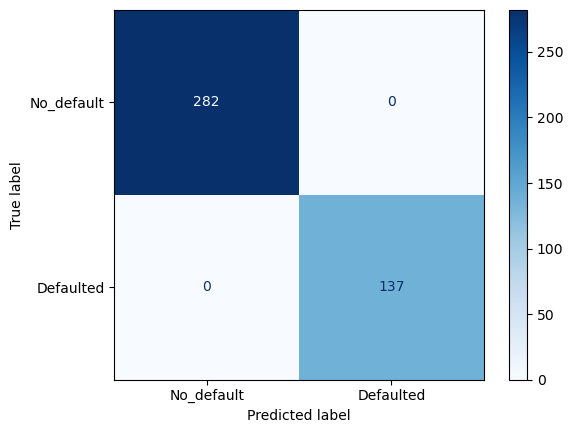

In [37]:
ConfusionMatrixDisplay.from_predictions(
    y_true = y_test,
    y_pred = test_pred,
    display_labels=["No_default", "Defaulted"], # Custom label names
    cmap=plt.cm.Blues                      # Color theme
)

plt.show()

From the aove plot, it is seen that the LogisticRegression model accurately classified all the defaulters and non_defaulters in the dataset.

### Building the SVM Model

Since this is a binary classification problem, we will make use of the LinearSVC of Support Vector Machines

In [38]:
from sklearn.svm import LinearSVC

In [39]:
# Create an instance of the model
svc = LinearSVC()

In [40]:
# Fit the model
svc.fit(X_train_scaled, y_train)

LinearSVC()

In [43]:
# Making predictions on the training set
svc_pred = svc.predict(X_test_scaled)

In [45]:
# Evaluating the model performance
print('Test Accuracy: ', accuracy_score(svc_pred, y_test))

Test Accuracy:  1.0


LinearSVC model also performed well on the dataset, having an accuracy of 100% on the test set.

In [46]:
### Checking using SVC (non-linear classifier) model
from sklearn.svm import SVC

In [47]:
svc_model = SVC()

In [48]:
svc_model.fit(X_train_scaled, y_train)

SVC()

In [49]:
y_pred = svc_model.predict(X_test_scaled)

In [50]:
print('Accuracy: ', accuracy_score(y_test, y_pred))

Accuracy:  0.9928400954653938


The SVC model has a 99.28% accuracy on the test set.

### Building the model without Standardization

#### Using LogistricRegression

In [56]:
# Create an Instance of the model
log_model = LogisticRegression()

In [57]:
# Fit the model
log_model.fit(X_train, y_train)

C:\Users\Itz_Ebuka\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [58]:
# Evaluating the model performance
print('Training Accuracy: ', log_model.score(X_train, y_train))

Training Accuracy:  0.9874551971326165


Without standardizing the numerical columns, the training accuracy dropped from 100% to 98.75%. 

In [60]:
print('Testing Accuracy: ', log_model.score(X_test, y_test))

Testing Accuracy:  0.9856801909307876


While the test accuracy dropped from 100% to 98.57% without standardizing the numerical columns.

Although without applying standardization, the training and testing accuracy is still considerably fine and acceptable. But the fact still stands that standardizing numericall columns actually helps to improve the model performance.